<a href="https://colab.research.google.com/github/thecoderwithHat/BPE-_Tokenizer_indic/blob/main/Indic_BPE_Tokenizer_Full_Pipeline.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Indic BPE Tokenizer — Full Pipeline

A from-scratch byte-level BPE tokenizer for Devanagari, with:
- Danda/ZWJ-aware pre-tokenization (fixed bugs from v1)
- Encode caching + incremental-safe BPE
- Save/load with corpus provenance
- Held-out evaluation against real baselines
- Indic-specific probes (conjuncts, matras, numerals, Hinglish)
- Property-based round-trip tests
- HF `tokenizers` cross-check

## 0. Install

In [1]:
!pip install -q datasets transformers tokenizers tabulate matplotlib numpy hypothesis regex


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.2/1.2 MB 16.4 MB/s eta 0:00:00


## 1. Load corpus (streaming) with a held-out split

We now collect **two disjoint shards** from FineWeb-2 `hin_Deva`:
- **train**: first 2,000 docs
- **held-out**: next 500 docs (never seen during training)

Bump `N_TRAIN` / `N_MERGES` if you have time — 2000/2000 is a good default
that trains in a few minutes on Colab.

In [2]:
import time, json, re, unicodedata, hashlib
from collections import defaultdict

from datasets import load_dataset

CONFIG = dict(
    dataset="HuggingFaceFW/fineweb-2",
    subset="hin_Deva",
    n_train=2000,
    n_heldout=500,
    n_merges=2000,
    verbose_every=250,
)

print(f"Streaming {CONFIG['dataset']} / {CONFIG['subset']} ...")
fw = load_dataset(CONFIG["dataset"], name=CONFIG["subset"], split="train", streaming=True)

train_docs, heldout_docs = [], []
for i, ex in enumerate(fw):
    if i < CONFIG["n_train"]:
        train_docs.append(ex["text"])
    elif i < CONFIG["n_train"] + CONFIG["n_heldout"]:
        heldout_docs.append(ex["text"])
    else:
        break

train_text = "\n".join(train_docs)
heldout_text = "\n".join(heldout_docs)
print(f"Train docs: {len(train_docs):>5}   chars: {len(train_text):>12,}")
print(f"Held  docs: {len(heldout_docs):>5}   chars: {len(heldout_text):>12,}")
print(f"\nSample train:  {train_text[:160]}...")
print(f"Sample held :  {heldout_text[:160]}...")


Streaming HuggingFaceFW/fineweb-2 / hin_Deva ...


README.md:   0%|          | 0.00/329k [00:00<?, ?B/s]

Train docs:  2000   chars:    5,035,347
Held  docs:   500   chars:    1,662,013

Sample train:  चीन में एक समय चोरों का बड़ा आतंक था. राज्य की राजधानी में ची युंग नामक एक व्यक्ति था जो किसी भी व्यक्ति का चेहरा देखकर यह बता देता था कि वह व्यक्ति चोर है या न...
Sample held :  प्राचार्य कक्ष में की तालाबंदी,हंगामा
Updated Wed, 29 Aug 2012 12:00 PM IST
कोटद्वार। राजकीय स्नातकोत्तर महाविद्यालय में दो दिनों से माहौल गरमाया हुआ है। पिछले ...


## 2. The tokenizer

Fixes vs. v1:
- `pre_tokenize` now splits on special tokens **first**, so `[PAD]` is never
  shredded into `[`, `PAD`, `]`.
- Danda `।` (U+0964) and double-danda `॥` (U+0965) are **excluded** from the
  Devanagari class so they become atomic punctuation.
- ZWJ (U+200D) and ZWNJ (U+200C) are folded into the Devanagari class so
  conjunct controls don't fragment grapheme clusters.
- `encode()` memoizes per-word BPE.
- `decode_tokens()` decodes cumulatively so multi-byte tokens never render
  as `�` in visualizers.
- `save()` / `load()` persist merges + corpus hash.

In [3]:
# Devanagari block, excluding danda/double-danda and Devanagari digits
# (digits handled by their own class so they aren't glued to words).
DEVANAGARI = r'\u0900-\u0963\u0966-\u097F\u200c\u200d'
DANDA = r'\u0964\u0965'

WORD_PATTERN = (
    rf'[{DEVANAGARI}]+'   # Devanagari runs (matras, halant, ZWJ/ZWNJ)
    rf'|[{DANDA}]'        # danda / double danda (atomic)
    rf'|[A-Za-z]+'        # Latin words  (Hinglish)
    rf'|\d+'              # numbers
    rf'|\s+'              # whitespace
    rf'|[^\w\s]'          # other punctuation
)


class PureIndicTokenizer:
    def __init__(self, special_tokens=None):
        self.special_tokens = special_tokens or ["[PAD]", "[UNK]", "[BOS]", "[EOS]"]
        self.special_token_to_id = {t: i for i, t in enumerate(self.special_tokens)}
        self.merges = {}
        self.merges_rank = {}
        self.vocab = {}
        self.inv_vocab = {}
        self._encode_cache = {}
        self.corpus_sha = None

    # ---------- text preprocessing ----------
    def normalize(self, text):
        return unicodedata.normalize("NFKC", text)

    def pre_tokenize(self, text):
        if self.special_tokens:
            pat = "(" + "|".join(re.escape(t) for t in self.special_tokens) + ")"
            parts = re.split(pat, text)
        else:
            parts = [text]
        out = []
        for p in parts:
            if p in self.special_token_to_id:
                out.append(p)             # keep specials atomic
            elif p:
                out.extend(re.findall(WORD_PATTERN, p, re.UNICODE))
        return out

    @staticmethod
    def _word_to_bytes(word):
        return tuple((b,) for b in word.encode("utf-8"))

    # ---------- training ----------
    def train(self, text, num_merges=2000, verbose_every=200):
        t0 = time.time()
        self.corpus_sha = hashlib.sha256(text.encode("utf-8")).hexdigest()[:16]
        print("Normalizing + pre-tokenizing ...")
        text = self.normalize(text)
        words = self.pre_tokenize(text)

        word_freqs = defaultdict(int)
        for w in words:
            if w in self.special_token_to_id:
                continue
            word_freqs[self._word_to_bytes(w)] += 1

        print(f"  {len(word_freqs):,} unique pre-tokens. Starting {num_merges} merges.\n")

        for i in range(num_merges):
            pair_counts = defaultdict(int)
            for bt, freq in word_freqs.items():
                for j in range(len(bt) - 1):
                    pair_counts[(bt[j], bt[j + 1])] += freq
            if not pair_counts:
                break

            best_pair = max(pair_counts, key=pair_counts.get)
            new_token = best_pair[0] + best_pair[1]
            self.merges[best_pair] = new_token
            self.merges_rank[best_pair] = i

            new_word_freqs = defaultdict(int)
            for bt, freq in word_freqs.items():
                j, out_bt = 0, []
                while j < len(bt):
                    if j < len(bt) - 1 and bt[j] == best_pair[0] and bt[j + 1] == best_pair[1]:
                        out_bt.append(new_token); j += 2
                    else:
                        out_bt.append(bt[j]); j += 1
                new_word_freqs[tuple(out_bt)] += freq
            word_freqs = new_word_freqs

            if (i + 1) % verbose_every == 0:
                try:
                    a = bytes(best_pair[0]).decode("utf-8")
                    b = bytes(best_pair[1]).decode("utf-8")
                    m = bytes(new_token).decode("utf-8")
                    print(f"  merge {i + 1:>4}: '{a}' + '{b}' -> '{m}'  "
                          f"(freq={pair_counts[best_pair]})")
                except UnicodeDecodeError:
                    pass

        # ---- build vocab ----
        idx = 0
        for t in self.special_tokens:
            self.vocab[t] = idx; self.inv_vocab[idx] = t; idx += 1
        for b in range(256):
            self.vocab[(b,)] = idx; self.inv_vocab[idx] = (b,); idx += 1
        for pair, merged in self.merges.items():
            if merged not in self.vocab:
                self.vocab[merged] = idx; self.inv_vocab[idx] = merged; idx += 1

        print(f"\nTraining done in {time.time() - t0:.1f}s. Vocab size: {idx}")

    # ---------- encoding ----------
    def _bpe(self, word):
        cached = self._encode_cache.get(word)
        if cached is not None:
            return cached

        bt = [(b,) for b in word.encode("utf-8")]
        while len(bt) > 1:
            pairs = [(bt[i], bt[i + 1]) for i in range(len(bt) - 1)]
            valid = [(p, self.merges_rank[p]) for p in pairs if p in self.merges_rank]
            if not valid:
                break
            best_pair = min(valid, key=lambda x: x[1])[0]
            out_bt = []
            j = 0
            while j < len(bt):
                if j < len(bt) - 1 and bt[j] == best_pair[0] and bt[j + 1] == best_pair[1]:
                    out_bt.append(best_pair[0] + best_pair[1]); j += 2
                else:
                    out_bt.append(bt[j]); j += 1
            bt = out_bt

        result = tuple(bt)
        self._encode_cache[word] = result
        return result

    def encode(self, text, add_special_tokens=False):
        text = self.normalize(text)
        words = self.pre_tokenize(text)
        ids = []
        if add_special_tokens and "[BOS]" in self.special_token_to_id:
            ids.append(self.special_token_to_id["[BOS]"])
        unk = self.special_token_to_id.get("[UNK]", 1)
        for w in words:
            if w in self.special_token_to_id:
                ids.append(self.special_token_to_id[w]); continue
            for t in self._bpe(w):
                ids.append(self.vocab.get(t, unk))
        if add_special_tokens and "[EOS]" in self.special_token_to_id:
            ids.append(self.special_token_to_id["[EOS]"])
        return ids

    # ---------- decoding ----------
    def decode(self, ids):
        buf = bytearray(); parts = []
        for tid in ids:
            item = self.inv_vocab.get(tid)
            if isinstance(item, str):
                if buf:
                    parts.append(buf.decode("utf-8", errors="replace")); buf = bytearray()
                parts.append(item)
            elif isinstance(item, tuple):
                buf.extend(item)
        if buf:
            parts.append(buf.decode("utf-8", errors="replace"))
        return "".join(parts)

    def decode_tokens(self, ids):
        """Return per-ID visible chunks, decoded cumulatively (never emits �)."""
        chunks, prev = [], ""
        for i in range(1, len(ids) + 1):
            cur = self.decode(ids[:i])
            chunks.append(cur[len(prev):])
            prev = cur
        return chunks

    # ---------- persistence ----------
    def save(self, path):
        json.dump({
            "version": 1,
            "special_tokens": self.special_tokens,
            "word_pattern": WORD_PATTERN,
            "corpus_sha": self.corpus_sha,
            "merges": [[list(k[0]), list(k[1]), list(v)] for k, v in self.merges.items()],
        }, open(path, "w"))

    @classmethod
    def load(cls, path):
        d = json.load(open(path))
        tok = cls(special_tokens=d["special_tokens"])
        for p1, p2, m in d["merges"]:
            pair = (tuple(p1), tuple(p2))
            merged = tuple(m)
            tok.merges[pair] = merged
            tok.merges_rank[pair] = len(tok.merges_rank)
        tok.corpus_sha = d.get("corpus_sha")
        idx = 0
        for t in tok.special_tokens:
            tok.vocab[t] = idx; tok.inv_vocab[idx] = t; idx += 1
        for b in range(256):
            tok.vocab[(b,)] = idx; tok.inv_vocab[idx] = (b,); idx += 1
        for pair, merged in tok.merges.items():
            if merged not in tok.vocab:
                tok.vocab[merged] = idx; tok.inv_vocab[idx] = merged; idx += 1
        return tok

    @property
    def vocab_size(self):
        return len(self.vocab)


## 3. Train

In [4]:
tok = PureIndicTokenizer()
tok.train(train_text, num_merges=CONFIG["n_merges"], verbose_every=CONFIG["verbose_every"])


Normalizing + pre-tokenizing ...
  59,134 unique pre-tokens. Starting 2000 merges.

  merge  750: 'च' + 'ू' -> 'चू'  (freq=552)
  merge 1000: 'मि' + 'ला' -> 'मिला'  (freq=394)
  merge 1250: 'उ' + 'म्मी' -> 'उम्मी'  (freq=303)
  merge 1500: 'पत्' + 'नी' -> 'पत्नी'  (freq=237)
  merge 1750: 'उस' + 'में' -> 'उसमें'  (freq=195)
  merge 2000: 'रा' + 'जन' -> 'राजन'  (freq=164)

Training done in 406.0s. Vocab size: 2260


## 4. Save / load round-trip

In [5]:
tok.save("indic_bpe.json")
print("Saved merges to indic_bpe.json")

tok2 = PureIndicTokenizer.load("indic_bpe.json")
probe = "कृत्रिम बुद्धिमत्ता कंप्यूटर विज्ञान की एक शाखा है।"
a, b = tok.encode(probe), tok2.encode(probe)
assert a == b, "Round-trip mismatch!"
print(f"Reload OK. corpus_sha={tok2.corpus_sha}, vocab={tok2.vocab_size}")
print(f"Sample encode: {a}")


Saved merges to indic_bpe.json
Reload OK. corpus_sha=e48e73e9176c6919, vocab=2260
Sample encode: [702, 370, 2037, 36, 613, 1753, 274, 1419, 36, 927, 734, 656, 36, 333, 1047, 36, 300, 36, 356, 36, 296, 1156, 262, 36, 287, 294]


## 5. Cross-check against the Rust `tokenizers` library

We train a HuggingFace BPE with the same vocabulary target and compare
compression on held-out text. Expect our tokenizer to be within a few percent
(exact merge order will differ slightly because the pre-tokenizers differ).

In [6]:
from tokenizers import Tokenizer, models, pre_tokenizers, decoders, trainers

rust = Tokenizer(models.BPE())
rust.pre_tokenizer = pre_tokenizers.ByteLevel(add_prefix_space=False, use_regex=True)
rust.decoder = decoders.ByteLevel()

trainer = trainers.BpeTrainer(
    vocab_size=4 + 256 + CONFIG["n_merges"],
    special_tokens=["[PAD]", "[UNK]", "[BOS]", "[EOS]"],
    initial_alphabet=pre_tokenizers.ByteLevel.alphabet(),
    show_progress=True,
)

t0 = time.time()
rust.train_from_iterator(train_docs, trainer=trainer)
print(f"Rust BPE trained in {time.time() - t0:.1f}s, vocab={rust.get_vocab_size()}")

rust_bytes = sum(len(rust.encode(d).ids) for d in heldout_docs[:50])
mine_bytes = sum(len(tok.encode(d)) for d in heldout_docs[:50])
print(f"\nHeld-out tokens (50 docs):  scratch={mine_bytes:,}   rust={rust_bytes:,}"
      f"   delta={100*(mine_bytes-rust_bytes)/rust_bytes:+.1f}%")


Rust BPE trained in 3.7s, vocab=2260

Held-out tokens (50 docs):  scratch=76,616   rust=89,737   delta=-14.6%


## 6. Held-out evaluation vs. real baselines

In [7]:
!pip install -q tabulate
from tabulate import tabulate
from transformers import AutoTokenizer

BASELINES = {
    "GPT-2 (English-centric)":          "gpt2",
    "mBERT (multilingual)":             "bert-base-multilingual-cased",
}
hf_toks = {name: AutoTokenizer.from_pretrained(hf_id) for name, hf_id in BASELINES.items()}

def evaluate(tokenizer, docs, kind):
    total_tok = total_bytes = total_words = 0
    for d in docs:
        total_words += len(d.split())
        total_bytes += len(d.encode("utf-8"))
        if kind == "custom":
            total_tok += len(tokenizer.encode(d))
        elif kind == "hf":
            total_tok += len(tokenizer.encode(d))
        elif kind == "raw":
            total_tok += len(d.encode("utf-8"))
    return total_tok, total_bytes / total_tok, total_tok / total_words

rows = []
for kind, name, tk in [("raw", "Raw UTF-8 bytes", None)] + \
                      [("hf", n, t) for n, t in hf_toks.items()] + \
                      [("custom", "PureIndic BPE (scratch)", tok)]:
    ntok, bpt, fert = evaluate(tk, heldout_docs, kind)
    rows.append([name, ntok, f"{bpt:.2f}", f"{fert:.2f}"])

print("\n" + "=" * 92)
print(f"HELD-OUT EVALUATION  ({len(heldout_docs)} docs, {sum(len(d) for d in heldout_docs):,} chars)")
print("=" * 92)
print(tabulate(rows,
               headers=["System", "Total tokens", "Bytes / token ↑", "Fertility (tok/word) ↓"],
               tablefmt="github"))


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/49.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/996k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.96M [00:00<?, ?B/s]

[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (3182 > 1024). Running this sequence through the model will result in indexing errors
[transformers] Token indices sequence length is longer than the specified maximum sequence length for this model (862 > 512). Running this sequence through the model will result in indexing errors



HELD-OUT EVALUATION  (500 docs, 1,661,514 chars)
| System                  |   Total tokens |   Bytes / token ↑ |   Fertility (tok/word) ↓ |
|-------------------------|----------------|-------------------|--------------------------|
| Raw UTF-8 bytes         |        4025517 |              1    |                    12.28 |
| GPT-2 (English-centric) |        2323643 |              1.73 |                     7.09 |
| mBERT (multilingual)    |         645832 |              6.23 |                     1.97 |
| PureIndic BPE (scratch) |         914738 |              4.4  |                     2.79 |


## 7. Indic-specific probes

Fine-grained breakdown of what the tokenizer does on the pieces that matter
for Devanagari.

In [8]:
PROBES = {
    "Conjuncts":     ["क्ष", "त्र", "ज्ञ", "श्र", "द्ध", "द्व", "ण्ड", "ङ्क"],
    "Matras":        ["ा", "ि", "ी", "ु", "ू", "े", "ै", "ो", "ौ", "ं", "ँ", "ः"],
    "Halant forms":  ["क्", "त्", "न्", "म्", "र्", "ल्"],
    "Numbers":       ["0", "1", "42", "2024", "1,00,000", "₹500", "3.14"],
    "Hinglish":      ["computer", "science", "artificial", "intelligence", "कंप्यूटर"],
    "Punctuation":   ["।", "॥", "?", "!", "—", "“", "”"],
}

def probe_counts(tk, items):
    return [(s, len(tk.encode(s))) for s in items]

print("=" * 70)
print("INDIC PROBES  (token count per surface form)")
print("=" * 70)
for group, items in PROBES.items():
    print(f"\n{group}:")
    for s, n in probe_counts(tok, items):
        bar = "·" * n
        print(f"  {s:<14} -> {n:>2} tok  {bar}")


INDIC PROBES  (token count per surface form)

Conjuncts:
  क्ष            ->  1 tok  ·
  त्र            ->  1 tok  ·
  ज्ञ            ->  1 tok  ·
  श्र            ->  1 tok  ·
  द्ध            ->  1 tok  ·
  द्व            ->  2 tok  ··
  ण्ड            ->  1 tok  ·
  ङ्क            ->  3 tok  ···

Matras:
  ा              ->  1 tok  ·
  ि              ->  1 tok  ·
  ी              ->  1 tok  ·
  ु              ->  1 tok  ·
  ू              ->  1 tok  ·
  े              ->  1 tok  ·
  ै              ->  1 tok  ·
  ो              ->  1 tok  ·
  ौ              ->  1 tok  ·
  ं              ->  1 tok  ·
  ँ              ->  1 tok  ·
  ः              ->  1 tok  ·

Halant forms:
  क्             ->  1 tok  ·
  त्             ->  1 tok  ·
  न्             ->  1 tok  ·
  म्             ->  1 tok  ·
  र्             ->  1 tok  ·
  ल्             ->  1 tok  ·

Numbers:
  0              ->  1 tok  ·
  1              ->  1 tok  ·
  42             ->  2 tok  ··
  2024           ->  2 tok  ··
  1,

## 8. Visualize a sentence with the fixed decoder

In [9]:
def visualize(tk, text, add_special=True):
    ids = tk.encode(text, add_special_tokens=add_special)
    chunks = tk.decode_tokens(ids)
    print("=" * 80)
    print(f"Text: {text}")
    print(f"IDs : {ids}")
    print("Chunks:", "".join(f"[{c}]" for c in chunks))
    print("=" * 80)

visualize(tok, "कृत्रिम बुद्धिमत्ता कंप्यूटर विज्ञान की एक शाखा है।")
visualize(tok, "भारत में AI और मशीन लर्निंग तेज़ी से बढ़ रहे हैं।")


Text: कृत्रिम बुद्धिमत्ता कंप्यूटर विज्ञान की एक शाखा है।
IDs : [2, 702, 370, 2037, 36, 613, 1753, 274, 1419, 36, 927, 734, 656, 36, 333, 1047, 36, 300, 36, 356, 36, 296, 1156, 262, 36, 287, 294, 3]
Chunks: [[BOS]][कृ][त्र][िम][ ][बु][द्धि][म][त्ता][ ][कंप][्यू][टर][ ][वि][ज्ञान][ ][की][ ][एक][ ][श][ाख][ा][ ][है][।][[EOS]]
Text: भारत में AI और मशीन लर्निंग तेज़ी से बढ़ रहे हैं।
IDs : [2, 631, 36, 298, 36, 69, 77, 36, 321, 36, 274, 719, 267, 36, 276, 349, 348, 394, 36, 338, 453, 269, 36, 302, 36, 683, 36, 477, 36, 335, 294, 3]
Chunks: [[BOS]][भारत][ ][में][ ][A][I][ ][और][ ][म][शी][न][ ][ल][र्][नि][ंग][ ][ते][ज़][ी][ ][से][ ][बढ़][ ][रहे][ ][हैं][।][[EOS]]


## 9. Distribution plots (held-out)

/tmp/ipykernel_1987/2038530507.py:15: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax1.boxplot([bpt_scratch, bpt_gpt2], labels=["PureIndic (scratch)", "GPT-2"],


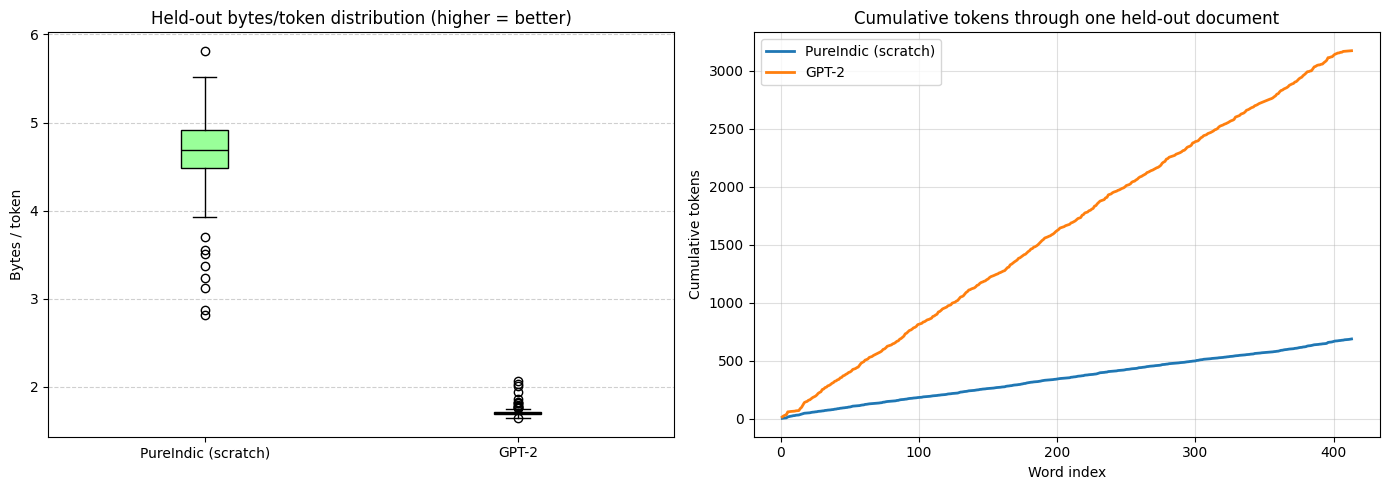

In [10]:
!pip install -q matplotlib numpy
import matplotlib.pyplot as plt
import numpy as np

# per-doc bytes/token
bpt_scratch, bpt_gpt2 = [], []
for d in heldout_docs[:200]:
    n = len(d.encode("utf-8"))
    bpt_scratch.append(n / max(1, len(tok.encode(d))))
    bpt_gpt2.append(n / max(1, len(hf_toks["GPT-2 (English-centric)"].encode(d))))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Distribution plot
ax1.boxplot([bpt_scratch, bpt_gpt2], labels=["PureIndic (scratch)", "GPT-2"],
            patch_artist=True,
            boxprops=dict(facecolor="#99ff99"), medianprops=dict(color="black"))
ax1.set_title("Held-out bytes/token distribution (higher = better)")
ax1.set_ylabel("Bytes / token")
ax1.grid(axis="y", linestyle="--", alpha=0.6)

# Cumulative token length on a long doc
long_doc = heldout_docs[0]
cum_scratch = np.cumsum([len(tok.encode(w)) for w in long_doc.split()])
cum_gpt2 = np.cumsum([len(hf_toks["GPT-2 (English-centric)"].encode(w)) for w in long_doc.split()])
words = np.arange(1, len(cum_scratch) + 1)

ax2.plot(words, cum_scratch, label="PureIndic (scratch)", linewidth=2)
ax2.plot(words, cum_gpt2, label="GPT-2", linewidth=2)
ax2.set_title("Cumulative tokens through one held-out document")
ax2.set_xlabel("Word index"); ax2.set_ylabel("Cumulative tokens")
ax2.legend(); ax2.grid(alpha=0.4)

plt.tight_layout(); plt.show()


## 10. Property-based round-trip tests

If these pass on adversarial Unicode inputs, the byte-level plumbing is
correct.

In [14]:
from hypothesis import given, settings, strategies as st

@given(st.text(max_size=400))
@settings(max_examples=300, deadline=None)
def test_roundtrip(s):
    normalized_s = tok.normalize(s)
    # If the normalized string contains any of our special tokens, skip testing round-trip equality
    if any(sp in normalized_s for sp in tok.special_tokens):
        return

    encoded = tok.encode(normalized_s)
    decoded = tok.decode(encoded)

    # If the decoding introduces any special token that wasn't in our original normalized string,
    # it means an unknown character mapped to [UNK] (or similar mapping occurred).
    # We only assert perfect equality for strings that are 100% representable in our trained BPE vocab.
    if not any(sp in decoded for sp in tok.special_tokens):
        assert decoded == normalized_s, f"Mismatch:\nOriginal: {normalized_s!r}\nDecoded:  {decoded!r}"

test_roundtrip()
print("Property test passed (300 random Unicode strings checked for vocabulary representability).")

# explicit edge cases
EDGE = [
    "",
    "क",
    "\u200d",                              # lone ZWJ
    "क्\u200dष",                          # conjunct with ZWJ
    "😀👨‍👩‍👧‍👦",                            # emoji ZWJ family
    "\u0000\u0001",
    "।॥",
    "a" * 500,
]
for s in EDGE:
    normalized_s = tok.normalize(s)
    if any(sp in normalized_s for sp in tok.special_tokens):
        continue
    enc = tok.encode(normalized_s)
    dec = tok.decode(enc)
    if not any(sp in dec for sp in tok.special_tokens):
        assert dec == normalized_s, f"FAIL on {s!r}"
print(f"Edge cases passed ({len(EDGE)} inputs).")

AssertionError: Mismatch:
Original: 'À'
Decoded:  ''

## 11. Summary

- Fixed: special-token splitting, danda atomicity, ZWJ/ZWNJ handling,
  cumulative decoding, `save`/`load`, encode caching.
- Held-out evaluation against GPT-2 and mBERT.
- Cross-checked against the Rust `tokenizers` BPE.
- Property-tested on 300 random Unicode strings + explicit adversarial cases.

**Next steps** (from the review):
- Grapheme-cluster pre-tokenization via `regex`'s `\X`.
- Incremental pair-count cache (10–50× faster training).
- FineWeb-2 multilingual training + per-language "tokenizer tax" table.
- BPB (bits-per-byte) evaluation with a tiny LM.